In [2]:
!pip install datasets

In [3]:
!pip uninstall -y datasets huggingface-hub # desinstalamos las dos librerias para evitar errores en la ejecución.
!pip install datasets==2.14.6 huggingface-hub==0.16.4 # volvemos a instalar las versiones específicas compatibels.

Found existing installation: datasets 4.0.0
Uninstalling datasets-4.0.0:
  Successfully uninstalled datasets-4.0.0
Found existing installation: huggingface_hub 1.23.0
Uninstalling huggingface_hub-1.23.0:
  Successfully uninstalled huggingface_hub-1.23.0
INFO: pip is looking at multiple versions of multiprocess to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 493.7/493.7 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.8/268.8 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.3/115.3 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.4/135.4 kB 7.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: dill
    F

In [4]:
# importación de las librerias necesarias para clasificación de texto usando Pytorch
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import random
from datasets import load_dataset
from torch.utils.data import Dataset, DataLoader, random_split

In [5]:
# esta arquitectura tendra una sóla semilla para todas las activaciones
SEED = 42

def set_seed(seed=SEED):
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

set_seed()


In [6]:
# verificamos la unidad de procesamiento cuda (GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [7]:
# cargamos el dataset AG News: noticias en 4 clases: World(0), Sports(1), Business(2), Sci/Tech(3)
from datasets import disable_caching
disable_caching()
raw = load_dataset("ag_news", revision='main')
print(raw)
print(raw["train"][0])

Extracting data files:   0%|          | 0/2 [00:00<?, ?it/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [8]:
# tomamos un subconjunto para poder iterar mas rapido, train=20000, test=2000
#N_TRAIN = 20000
#N_TEST = 2000

# fijamos la semilla antes de barajar con shuffle
#train_raw = raw["train"].shuffle(seed=SEED).select(range(N_TRAIN))
#test_raw = raw["test"].shuffle(seed=SEED).select(range(N_TEST))

# si deseamos trabajar con todo el dataset train (120000), val (7600)
train_raw = raw["train"].shuffle(seed=SEED)
test_raw  = raw["test"].shuffle(seed=SEED)


#print(f"tamaño del subconjunto de entrenamiento: {len(train_raw)}")
#print(f"tamaño del subconjunto de test: {len(test_raw)}")
#print(f"ejemplos de test: {train_raw[0]}")

# distribución de las clases y balance
labels = np.array(train_raw["label"])
for c in range(4):
  print(f"Clase {c}: {(labels==c).sum()} ejemplos")


Clase 0: 30000 ejemplos
Clase 1: 30000 ejemplos
Clase 2: 30000 ejemplos
Clase 3: 30000 ejemplos


In [9]:
# proceso de tokenización simple, pasar el texto a una lista de palabras en minúsculas
import re
from collections import Counter

def tokenize(text):
  text = text.lower()
  tokens = re.findall(r"[a-z0-9]+", text)
  return tokens

print(tokenize(train_raw["text"][0]))
#print(tokenize(raw["train"][0]["text"])) # imprime los tokens de la primer noticia del conjunto de entrenamiento completo

['bangladesh', 'paralysed', 'by', 'strikes', 'opposition', 'activists', 'have', 'brought', 'many', 'towns', 'and', 'cities', 'in', 'bangladesh', 'to', 'a', 'halt', 'the', 'day', 'after', '18', 'people', 'died', 'in', 'explosions', 'at', 'a', 'political', 'rally']


In [10]:
# TOKENS ESPECIALES
PAD_TOKEN = "<pad>"   # relleno para igualar longitudes en un batch
UNK_TOKEN = "<unk>"   # palabra fuera del vocabulario
CLS_TOKEN = "<cls>"   # token resumen para clasificar (estilo BERT)

PAD_IDX = 0
UNK_IDX = 1
CLS_IDX = 2

In [11]:
# construcción del vocabulario
# se recorre sólo el train contando las palabras mas frecuentes en orden hasta el valor maximo del vocabulario
# las palabras con frecuencia menor al minimo 2 caen un <unk>
MAX_VOCAB = 20000
MIN_FREQ = 2

def build_vocab(dataset, max_vocab=MAX_VOCAB, min_freq=MIN_FREQ):
  counter = Counter()

  for text in dataset:
    counter.update(tokenize(text))

  itos = [PAD_TOKEN, UNK_TOKEN, CLS_TOKEN] # la lista empieza con los tokens especiales en las posiciones fijas 0, 1 y 2

  for palabra, freq in counter.most_common():
      if freq < min_freq:
        break
      if len(itos) >= max_vocab:
        break
      itos.append(palabra) # añade las palabras mas comunes a la lista itos hasta Max_voc

  stoi = {palabra: idx for idx, palabra in enumerate(itos)}
  return stoi, itos

stoi, itos = build_vocab(train_raw["text"])
print("Tamaño del vocabulario:", len(itos))
print("Primeros 10 tokens:", itos[:10])
print("ID de la palabra 'the':", stoi.get("the"))
print("ID de una palabra rara inventada:", stoi.get("asdfghjkl", UNK_IDX))


Tamaño del vocabulario: 20000
Primeros 10 tokens: ['<pad>', '<unk>', '<cls>', 'the', 'to', 'a', 'of', 'in', 'and', 's']
ID de la palabra 'the': 3
ID de una palabra rara inventada: 1


In [12]:
# construye la lista de IDS de los tokens con el toquen especial <cls> al inicio
def encode(text):
    tokens = tokenize(text)
    ids = [CLS_IDX]
    for tok in tokens:
        ids.append(stoi.get(tok, UNK_IDX))
    return ids

# prueba
ejemplo = train_raw["text"][0]
print("Texto:", ejemplo[:60], "...")
print("IDs  :", encode(ejemplo)[:15])

Texto: Bangladesh paralysed by strikes Opposition activists have br ...
IDs  : [2, 2012, 1, 20, 1924, 771, 3609, 37, 1474, 326, 5459, 8, 2070, 7, 2012]


In [13]:
# crear un dataset personalizado compatible con pytorch
# con esto se adapta el dataset de Hugging Face para que pueda leerse con DataLoader de Pytorch
class AGNewsDataset(Dataset):
  def __init__(self, hf_dataset, max_len=64):
    self.textos = hf_dataset["text"]
    self.labels = hf_dataset["label"]
    self.max_len = max_len

  def __len__(self):
      return len(self.labels)

  def __getitem__(self, idx):
    ids = encode(self.textos[idx])[:self.max_len]
    return torch.tensor(ids), torch.tensor(self.labels[idx])

MAX_LEN = 64  # truncar a 64 tokens es adecuado para acelerar el proceso y para la longitud d elas noticias
full_train_dataset = AGNewsDataset(train_raw, max_len = MAX_LEN)
test_dataset = AGNewsDataset(test_raw, max_len = MAX_LEN)

# pruebando un ejemplo
ids, label = full_train_dataset[0]
print("IDs shape:", ids.shape)
print("IDs:", ids[:12])
print("Label:", label)


IDs shape: torch.Size([30])
IDs: tensor([   2, 2012,    1,   20, 1924,  771, 3609,   37, 1474,  326, 5459,    8])
Label: tensor(0)


In [14]:
# División del dataset en train y val ya como tensores, similar a los laboratorios de clases
set_seed()
train_size = int(0.9*len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

print(f"Tamaño del conjunto de entrenamiento: {len(train_dataset)}")
print(f"Tamaño del conjunto de validaciíon: {len(val_dataset)}")

Tamaño del conjunto de entrenamiento: 108000
Tamaño del conjunto de validaciíon: 12000


In [15]:
# utilizar <pad> para rellenar espacios igualando longitud de tokens para cada noticia
# batch es una lista de tuplas [(id_1,label_1), (id_2,label_2),...]
from torch.nn.utils.rnn import pad_sequence

def collate_fn(batch):
  secuencias = [item[0] for item in batch]
  labels = [item[1] for item in batch]

  # pad_sequence rellena con PAD_IDX hasta la más larga del batch
  # batch_first=True -> forma (batch_size, seq_len)
  padded = pad_sequence(secuencias, batch_first = True, padding_value=PAD_IDX)
  labels = torch.stack(labels)
  padding_mask = (padded == PAD_IDX)

  return padded, labels, padding_mask

# veamos tres ejemplos
batch_ejemplo = [full_train_dataset[i] for i in range(3)]

print(f"Batch original:")
for ids, label in batch_ejemplo:
  print(f"IDs: {ids}")
  print(f"Longitud: {len(ids)}")
  print(f"etiqueta: {label}")

# aplicamos collate_fn al batch_ejemplo
padded, labels, padding_mask = collate_fn(batch_ejemplo)

print(f"padded:")
print(padded)
print("Shape padded:", padded.shape)

print(f"\nLabels:")
print(labels)
print("Shape padded: {labels.shape}")

print(f"\npadding mask:")
print(padding_mask)
print("Shape padding mask:", padding_mask.shape)

Batch original:
IDs: tensor([   2, 2012,    1,   20, 1924,  771, 3609,   37, 1474,  326, 5459,    8,
        2070,    7, 2012,    4,    5, 1938,    3,  117,   30,  545,  104,  809,
           7, 2960,   16,    5,  562,  720])
Longitud: 30
etiqueta: 0
IDs: tensor([   2,    1, 4784, 2108,  243, 2372, 5060, 1275,  699,  209, 6056, 1154,
           7,    3, 5770,    8,  767,    4,    1,    5, 4730,    6, 4784,    7,
         152])
Longitud: 25
etiqueta: 1
IDs: tensor([    2,    29,  1125,    12,     9,   388,   338,   216,   340,  5370,
            1,   340,    24,    61,  2035,   264,     3,  6276,     6,  1370,
          432,    13, 19620,     7,     3,   511,  4265,     7,  3047,    10,
          788])
Longitud: 31
etiqueta: 0
padded:
tensor([[    2,  2012,     1,    20,  1924,   771,  3609,    37,  1474,   326,
          5459,     8,  2070,     7,  2012,     4,     5,  1938,     3,   117,
            30,   545,   104,   809,     7,  2960,    16,     5,   562,   720,
             0],
  

In [16]:
# construcción de los Batch con DataLoader
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle= True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

# ---- VERIFICACIÓN ----
X, y, mask = next(iter(train_loader))
print("X    (ids)  :", X.shape)      # (64, seq_len_del_batch)
print("y  (labels) :", y.shape)      # (64,)
print("mask        :", mask.shape)   # (64, seq_len_del_batch)
print("\nPrimera secuencia del batch:")
print(X[0])
print("\nSu máscara (True = padding):")
print(mask[0])

X    (ids)  : torch.Size([64, 64])
y  (labels) : torch.Size([64])
mask        : torch.Size([64, 64])

Primera secuencia del batch:
tensor([    2,  9846,   165,  1303,  1223,     1,     3,  2904,   165,  1350,
        10724,  5755,  3307,    18,   946,    10,     5,  6741,    11, 11255,
            8,   459,   743,   981,     4,  4681,     3,  3614,     6,  7242,
            8,  1350,   112,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
            0,     0,     0,     0])

Su máscara (True = padding):
tensor([False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False, False,
        False, False, False,  True,  True,  True,  True,  True,  True,  True,
         True,  True, 

In [17]:
# define una clase para la posición del tokens, utilizando la versión clasica PE (positional encoding)
# esto permite poner la atención también en la posición de las palabras.
# este método utiliza las funciones seno y coseno que no tienen parámetros entrenables como RoPE.
import math

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len=512):
    super() .__init__()

    pe = torch.zeros(max_len, d_model)
    position = torch.arange(0, max_len).unsqueeze(1).float()

    div_term = torch.exp(
        torch.arange(0, d_model, 2).float() * -(math.log(10000.0)/d_model)
    )

    pe[:, 0::2] = torch.sin(position * div_term)
    pe[:, 1::2] = torch.cos(position * div_term)

    pe = pe.unsqueeze(0)
    self.register_buffer("pe", pe)

  def forward(self, x):
        # x: (batch, seq_len, d_model)
        seq_len = x.size(1)
        return x + self.pe[:, :seq_len, :]

In [18]:
# funciones de activación a comparar
ACTIVATIONS = {
    "relu" : "relu",
    "gelu" : "gelu",
    "silu" : nn.SiLU(),
    "tanh" : nn.Tanh(),
}

In [19]:
# construcción del modelo transformer y la red neuronal
class TransformerModel(nn.Module):
  def __init__(
      self,
      vocab_size,
      activation= "relu",
      d_model = 128,
      nhead = 4,
      num_layers = 2,
      dim_feedforward = 256,
      num_clases = 4,
      dropout = 0.1,
      max_len = 512,
      ):

      super().__init__()

      self.activation_name = activation
      self.d_model = d_model

      # capas de la red
      self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
      self.pos_encoder = PositionalEncoding(d_model, max_len=max_len)
      self.dropout = nn.Dropout(dropout)

      # bloque encoder
      encoder_layer = nn.TransformerEncoderLayer(
          d_model=d_model,
          nhead=nhead,
          dim_feedforward=dim_feedforward,
          dropout=dropout,
          activation=ACTIVATIONS[activation],
          batch_first=True,
          norm_first=False,
      )

      self.encoder = nn.TransformerEncoder(
          encoder_layer,
          num_layers=num_layers,
          enable_nested_tensor=False,
      )
      # ultima capa
      self.fc = nn.Linear(d_model, num_clases)

      # inicialización
      nn.init.normal_(self.embedding.weight, mean=0, std=0.02)
      nn.init.zeros_(self.embedding.weight[PAD_IDX])
      nn.init.xavier_uniform_(self.fc.weight)
      nn.init.zeros_(self.fc.bias)

  def forward(self, x, padding_mask=None):
    x = self.embedding(x)*math.sqrt(self.d_model)
    x = self.pos_encoder(x)
    x = self.dropout(x)
    x = self.encoder(x, src_key_padding_mask=padding_mask)
    x = x[:, 0, :]
    x = self.fc(x)

    return x

In [20]:
# verificación del modelo antes de entrenar
set_seed()

modelo_prueba = TransformerModel(vocab_size=len(itos), activation= "relu").to(device)
X, y, mask = next(iter(train_loader))
X, mask = X.to(device), mask.to(device)

modelo_prueba.eval()

with torch.no_grad():
  logits = modelo_prueba(X, mask)
print("Entrada:", X.shape)
print("salida:", logits.shape)
print("params:", sum(p.numel() for p in modelo_prueba.parameters()))

for nombre in ACTIVATIONS:
  m = TransformerModel(vocab_size=len(itos), activation=nombre)
  print(f"{nombre}: ok")


Entrada: torch.Size([64, 64])
salida: torch.Size([64, 4])
params: 2825476
relu: ok
gelu: ok
silu: ok
tanh: ok


In [21]:
# validación
def validate(model, loader, criterion):
  model.eval()

  total_loss = 0
  correct = 0
  total = 0

  with torch.no_grad():
    for X, y, mask in loader:
      X, y, mask = X.to(device), y.to(device), mask.to(device)

      outputs = model(X, mask)
      loss = criterion(outputs, y)
      total_loss += loss.item()

      preds = outputs.argmax(dim=1)
      correct += (preds == y).sum().item()
      total += y.size(0)

  return total_loss/len(loader), correct/total

In [22]:
# norma del gradiente
def compute_grad_norm(model):
  total_norm = 0

  for p in model.parameters():
    if p.grad is not None:
      param_norm = p.grad.data.norm(2)
      total_norm += param_norm.item()**2

  return total_norm**0.5

In [23]:
# entrenamiento
def train_model(model, train_loader, val_loader, device, lr=1e-3, epochs=10):
  optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
  criterion = nn.CrossEntropyLoss()

  train_losses = []
  val_losses = []
  val_accuracies = []
  grad_norms = []

  for epoch in range(epochs):
    model.train()

    running_loss=0
    epoch_grad_norm = []

    for X, y, mask in train_loader:
      X, y, mask = X.to(device), y.to(device), mask.to(device)

      optimizer.zero_grad()

      outputs = model(X, mask)
      loss = criterion(outputs, y)

      loss.backward()

      grad_norm = compute_grad_norm(model)
      epoch_grad_norm.append(grad_norm)

      optimizer.step()

      running_loss += loss.item()

    train_loss = running_loss/len(train_loader)
    val_loss, val_acc = validate(model, val_loader, criterion)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    grad_norms.append(np.mean(epoch_grad_norm))
    print(
            f"Epoch {epoch+1}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_loss:.4f}, "
            f"val_acc={val_acc:.4f}, "
            f"grad_norm={grad_norms[-1]:.2f}"
        )

  return train_losses, val_losses, val_accuracies, grad_norms

In [24]:
# Hiperparametros fijos para entrenamiento
D_MODEL         = 128
NHEAD           = 4
NUM_LAYERS      = 2
DIM_FEEDFORWARD = 256
DROPOUT         = 0.1
LEARNING_RATE   = 1e-3
EPOCHS          = 10
NUM_CLASSES     = 4
# BATCH_SIZE = 64 y el split ya quedaron fijados en el Paso 3
print(EPOCHS)

10


In [25]:
# entrenamiento comparando las cuatro activaciones
results = {}
trained_models = {}

for activation in ["relu", "gelu", "silu", "tanh"]:
    print("\n" + "="*55)
    print("Training:", activation.upper())
    print("="*55)

    set_seed()   # <-- CLAVE: misma inicialización y mismo shuffle para todas

    model = TransformerModel(
        vocab_size=len(itos),
        activation=activation,
        d_model=D_MODEL,
        nhead=NHEAD,
        num_layers=NUM_LAYERS,
        dim_feedforward=DIM_FEEDFORWARD,
        num_clases=NUM_CLASSES,
        dropout=DROPOUT,
        max_len=MAX_LEN,
    ).to(device)

    print("EPOCHS que voy a pasar:", EPOCHS)
    metrics = train_model(
        model,
        train_loader,
        val_loader,
        device,
        lr=LEARNING_RATE,
        epochs=EPOCHS
    )

    results[activation] = metrics
    trained_models[activation] = model

print("\nEntrenamiento completo.")


Training: RELU
EPOCHS que voy a pasar: 10
Epoch 1: train_loss=0.3088, val_loss=0.2476, val_acc=0.9150, grad_norm=1.26
Epoch 2: train_loss=0.1771, val_loss=0.2530, val_acc=0.9146, grad_norm=0.75
Epoch 3: train_loss=0.1346, val_loss=0.2696, val_acc=0.9153, grad_norm=0.70
Epoch 4: train_loss=0.1064, val_loss=0.3132, val_acc=0.9135, grad_norm=0.68
Epoch 5: train_loss=0.0870, val_loss=0.3564, val_acc=0.9101, grad_norm=0.68
Epoch 6: train_loss=0.0717, val_loss=0.4608, val_acc=0.8967, grad_norm=0.66
Epoch 7: train_loss=0.0608, val_loss=0.3819, val_acc=0.9067, grad_norm=0.66
Epoch 8: train_loss=0.0528, val_loss=0.4569, val_acc=0.9005, grad_norm=0.65
Epoch 9: train_loss=0.0471, val_loss=0.4808, val_acc=0.9048, grad_norm=0.62
Epoch 10: train_loss=0.0435, val_loss=0.4770, val_acc=0.9063, grad_norm=0.65

Training: GELU
EPOCHS que voy a pasar: 10
Epoch 1: train_loss=0.3094, val_loss=0.2502, val_acc=0.9141, grad_norm=1.26
Epoch 2: train_loss=0.1791, val_loss=0.2639, val_acc=0.9127, grad_norm=0.75
E

In [26]:
# ---- BASELINE: MLP sobre embeddings promediados (tipo fastText) ----
# Sin atención, sin positional encoding, sin orden de palabras.
# Comparte vocabulario, split, loaders y funciones de entrenamiento
# con el Transformer: la ÚNICA diferencia es la arquitectura.

class BaselineModel(nn.Module):
    def __init__(self, vocab_size, d_model=128, hidden=256, num_classes=4, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=PAD_IDX)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(d_model, hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden, num_classes)

        nn.init.normal_(self.embedding.weight, mean=0.0, std=0.02)
        nn.init.zeros_(self.embedding.weight[PAD_IDX])
        nn.init.kaiming_normal_(self.fc1.weight, nonlinearity='relu')
        nn.init.zeros_(self.fc1.bias)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.zeros_(self.fc2.bias)

    def forward(self, x, padding_mask=None):
        # x: (batch, seq_len)
        emb = self.embedding(x)                          # (batch, seq_len, d_model)

        # promedio enmascarado: ignoramos las posiciones de <pad>
        if padding_mask is not None:
            valid = (~padding_mask).unsqueeze(-1).float()  # (batch, seq_len, 1)
            emb = emb * valid
            suma = emb.sum(dim=1)                          # (batch, d_model)
            conteo = valid.sum(dim=1).clamp(min=1)
            x = suma / conteo
        else:
            x = emb.mean(dim=1)

        x = self.dropout(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

In [27]:
# ---- ENTRENAMIENTO DEL BASELINE ----
# Mismas condiciones que el Transformer: misma semilla, mismo split,
# mismo batch size, mismo lr, mismas épocas.

print("="*55)
print("Training: BASELINE (MLP)")
print("="*55)

set_seed()

baseline = BaselineModel(
    vocab_size=len(itos),
    d_model=D_MODEL,
    hidden=DIM_FEEDFORWARD,
    num_classes=NUM_CLASSES,
    dropout=DROPOUT,
).to(device)

metrics_baseline = train_model(
    baseline,
    train_loader,
    val_loader,
    device,
    lr=LEARNING_RATE,
    epochs=EPOCHS
)

# lo guardamos en el mismo diccionario -> gráficas y tabla lo recogen solas
results["baseline"] = metrics_baseline
trained_models["baseline"] = baseline

# ---- COMPARACIÓN DE PARÁMETROS ----
n_base = sum(p.numel() for p in baseline.parameters())
n_trans = sum(p.numel() for p in trained_models["relu"].parameters())
print(f"\nParámetros baseline   : {n_base:,}")
print(f"Parámetros Transformer: {n_trans:,}")
print(f"Diferencia            : {n_trans - n_base:,}")

Training: BASELINE (MLP)
Epoch 1: train_loss=0.3130, val_loss=0.2420, val_acc=0.9195, grad_norm=0.34
Epoch 2: train_loss=0.1768, val_loss=0.2513, val_acc=0.9128, grad_norm=0.31
Epoch 3: train_loss=0.1332, val_loss=0.2790, val_acc=0.9119, grad_norm=0.29
Epoch 4: train_loss=0.1026, val_loss=0.3213, val_acc=0.9090, grad_norm=0.28
Epoch 5: train_loss=0.0792, val_loss=0.3802, val_acc=0.9039, grad_norm=0.26
Epoch 6: train_loss=0.0641, val_loss=0.4440, val_acc=0.9013, grad_norm=0.26
Epoch 7: train_loss=0.0490, val_loss=0.5090, val_acc=0.8995, grad_norm=0.24
Epoch 8: train_loss=0.0403, val_loss=0.5563, val_acc=0.9008, grad_norm=0.23
Epoch 9: train_loss=0.0336, val_loss=0.5919, val_acc=0.8936, grad_norm=0.21
Epoch 10: train_loss=0.0277, val_loss=0.6435, val_acc=0.8972, grad_norm=0.20

Parámetros baseline   : 2,594,052
Parámetros Transformer: 2,825,476
Diferencia            : 231,424


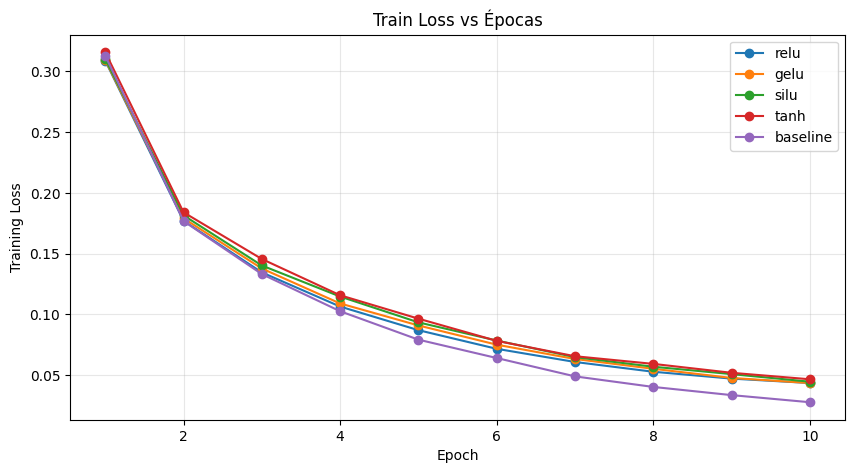

In [38]:
# Graficas para TRAIN LOSS
plt.figure(figsize=(10,5))
for act, (train_losses, _, _, _) in results.items():
    plt.plot(range(1, len(train_losses)+1), train_losses, marker='o', label=act)
plt.xlabel("Epoch"); plt.ylabel("Training Loss")
plt.title("Train Loss vs Épocas"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("train_loss.png", dpi=150, bbox_inches="tight")
plt.show()

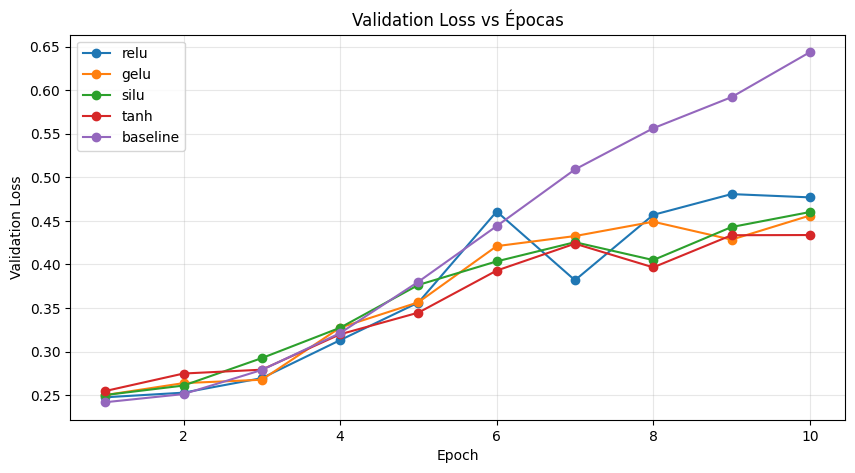

In [35]:
# Gráficas para VALIDATION LOSS
plt.figure(figsize=(10,5))
for act, (_, val_losses, _, _) in results.items():
    plt.plot(range(1, len(val_losses)+1), val_losses, marker='o', label=act)
plt.xlabel("Epoch"); plt.ylabel("Validation Loss")
plt.title("Validation Loss vs Épocas"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("validation_loss.png", dpi=150, bbox_inches="tight")
plt.show()

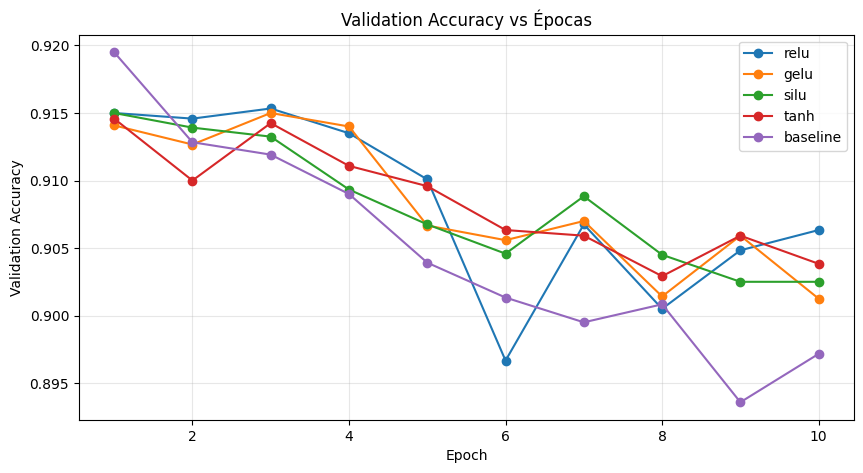

In [36]:
# Gráficas para VALIDATION ACCURACY
plt.figure(figsize=(10,5))
for act, (_, _, val_accs, _) in results.items():
    plt.plot(range(1, len(val_accs)+1), val_accs, marker='o', label=act)
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy")
plt.title("Validation Accuracy vs Épocas"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("validation_acc.png", dpi=150, bbox_inches="tight")
plt.show()

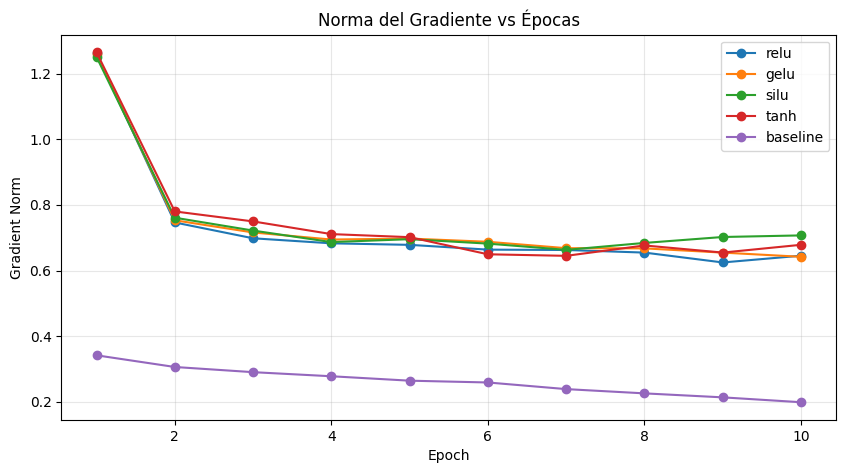

In [37]:
# Gráficas para GRADIENT NORM
plt.figure(figsize=(10,5))
for act, (_, _, _, grad_norms) in results.items():
    plt.plot(range(1, len(grad_norms)+1), grad_norms, marker='o', label=act)
plt.xlabel("Epoch"); plt.ylabel("Gradient Norm")
plt.title("Norma del Gradiente vs Épocas"); plt.legend(); plt.grid(alpha=0.3)
plt.savefig("norm_grad.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# TABLA COMPARATIVA FINAL
import pandas as pd

filas = []
for act, (train_losses, val_losses, val_accs, grad_norms) in results.items():
    filas.append({
        "Activación": act.upper(),
        "Mejor val loss": round(min(val_losses), 4),
        "Época mejor loss": int(np.argmin(val_losses)) + 1,
        "Mejor val accuracy": round(max(val_accs), 4),
        "Época mejor acc": int(np.argmax(val_accs)) + 1,
        "Val loss final": round(val_losses[-1], 4),
        "Grad norm medio": round(float(np.mean(grad_norms)), 2),
    })

tabla = pd.DataFrame(filas).sort_values("Mejor val accuracy", ascending=False)
print(tabla.to_string(index=False))

Activación  Mejor val loss  Época mejor loss  Mejor val accuracy  Época mejor acc  Val loss final  Grad norm medio
  BASELINE          0.2420                 1              0.9195                1          0.6435             0.26
      RELU          0.2476                 1              0.9153                3          0.4770             0.73
      GELU          0.2502                 1              0.9150                3          0.4561             0.74
      SILU          0.2503                 1              0.9150                1          0.4601             0.76
      TANH          0.2548                 1              0.9146                1          0.4338             0.75


In [33]:
# EVALUACIÓN E INFERENCIA

CLASES = ["World", "Sports", "Business", "Sci/Tech"]

def predecir(texto, model):
    model.eval()
    ids = encode(texto)[:MAX_LEN]
    X = torch.tensor(ids).unsqueeze(0).to(device)
    mask = (X == PAD_IDX)
    with torch.no_grad():
        logits = model(X, mask)
        probs = torch.softmax(logits, dim=1)[0]
    return CLASES[probs.argmax().item()], probs.cpu().numpy()


# ---- 1) ACCURACY GLOBAL EN TEST ----
criterion = nn.CrossEntropyLoss()
print("="*60)
print("EVALUACIÓN EN TEST SET")
print("="*60)
for act, model in trained_models.items():
    test_loss, test_acc = validate(model, test_loader, criterion)
    print(f"{act.upper():6s} -> test_loss={test_loss:.4f}, test_acc={test_acc:.4f}")


# ---- 2) NOTICIAS DEL TEST SET, LAS 4 ACTIVACIONES ----
print("\n" + "="*60)
print("CLASIFICACIÓN DE NOTICIAS DEL TEST SET")
print("="*60)

for i in range(5):
    texto = test_raw[i]["text"]
    real = CLASES[test_raw[i]["label"]]

    print(f"\nNoticia: {texto[:90]}...")
    print(f"Etiqueta real: {real}")
    for act, model in trained_models.items():
        pred, probs = predecir(texto, model)
        ok = "✓" if pred == real else "✗"
        print(f"  {act.upper():6s} -> {pred:9s} (p={probs.max():.3f}) {ok}")


# ---- 3) NOTICIAS EXTERNAS, LAS 4 ACTIVACIONES ----
print("\n" + "="*60)
print("CLASIFICACIÓN DE NOTICIAS EXTERNAS")
print("="*60)

noticias_externas = [
    "The stock market rallied today as investors welcomed strong earnings from major banks.",
    "Manchester United defeated Barcelona 3-1 in a thrilling Champions League match last night.",
    "Scientists discovered a new exoplanet orbiting a nearby star using the James Webb telescope.",
    "The president met with European leaders to discuss ongoing peace negotiations in the region.",
]

for texto in noticias_externas:
    print(f"\nNoticia: {texto[:90]}...")
    for act, model in trained_models.items():
        pred, probs = predecir(texto, model)
        print(f"  {act.upper():6s} -> {pred:9s} (p={probs.max():.3f})")

EVALUACIÓN EN TEST SET
RELU   -> test_loss=0.4482, test_acc=0.9093
GELU   -> test_loss=0.4428, test_acc=0.9087
SILU   -> test_loss=0.4354, test_acc=0.9072
TANH   -> test_loss=0.4201, test_acc=0.9111
BASELINE -> test_loss=0.6449, test_acc=0.8995

CLASIFICACIÓN DE NOTICIAS DEL TEST SET

Noticia: Indian board plans own telecast of Australia series The Indian cricket board said on Wedne...
Etiqueta real: Sports
  RELU   -> Sports    (p=0.986) ✓
  GELU   -> Sports    (p=0.995) ✓
  SILU   -> Sports    (p=0.999) ✓
  TANH   -> Sports    (p=0.988) ✓
  BASELINE -> World     (p=0.992) ✗

Noticia: Stocks Higher on Drop in Jobless Claims A sharp drop in initial unemployment claims and bu...
Etiqueta real: Business
  RELU   -> Business  (p=0.990) ✓
  GELU   -> Business  (p=0.825) ✓
  SILU   -> World     (p=0.653) ✗
  TANH   -> Business  (p=0.863) ✓
  BASELINE -> World     (p=0.787) ✗

Noticia: Nuggets 112, Raptors 106 Carmelo Anthony scored 30 points and Kenyon Martin added 24 point...
Etiqueta real

In [34]:
import torch, sys
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA:", torch.version.cuda)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")
import datasets; print("datasets:", datasets.__version__)

Python: 3.12.13
PyTorch: 2.11.0+cu128
CUDA: 12.8
GPU: Tesla T4
datasets: 2.14.6
